In [2]:
from pathlib import Path
import json
import pickle
import shutil
import os
import warnings
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from PIL import Image
import scanpy as sc
import seaborn as sns
from adjustText import adjust_text

warnings.filterwarnings('ignore', category=FutureWarning)

BASE = Path("..").resolve()
FIG_REPRO_DIR = BASE / 'FigureReproducing'
HUMAN_DIR = BASE / 'RealData_HumanBrainMERFISH'
NICHESCOPE_DIR = HUMAN_DIR / 'NicheScope'
STGP_OLI_DIR = HUMAN_DIR / 'Results' / 'stgp' / 'oli'
MCN_UNION_STGP_OLI_DIR = Path(os.environ.get('STGP_OLI_REFERENCE_DIR', str(STGP_OLI_DIR)))
NICHESCOPE_OLI_DIR = NICHESCOPE_DIR / 'results' / 'oli'
OUT_DIR = FIG_REPRO_DIR / 'human brain oli'
OUT_DIR.mkdir(parents=True, exist_ok=True)

from plot import (
    DPI,
    STYLE,
    draw_alpha_ci,
    ordered_gene_blocks,
    ordered_stgp_alpha,
    save_pair,
    spatial_program_values,
)

STGP_COLOR = '#E64B35'
NICHE_COLOR = '#3C5488'

plt.rcParams.update(STYLE)
adata_oli = sc.read_h5ad(STGP_OLI_DIR / 'adata_with_scores.h5ad')

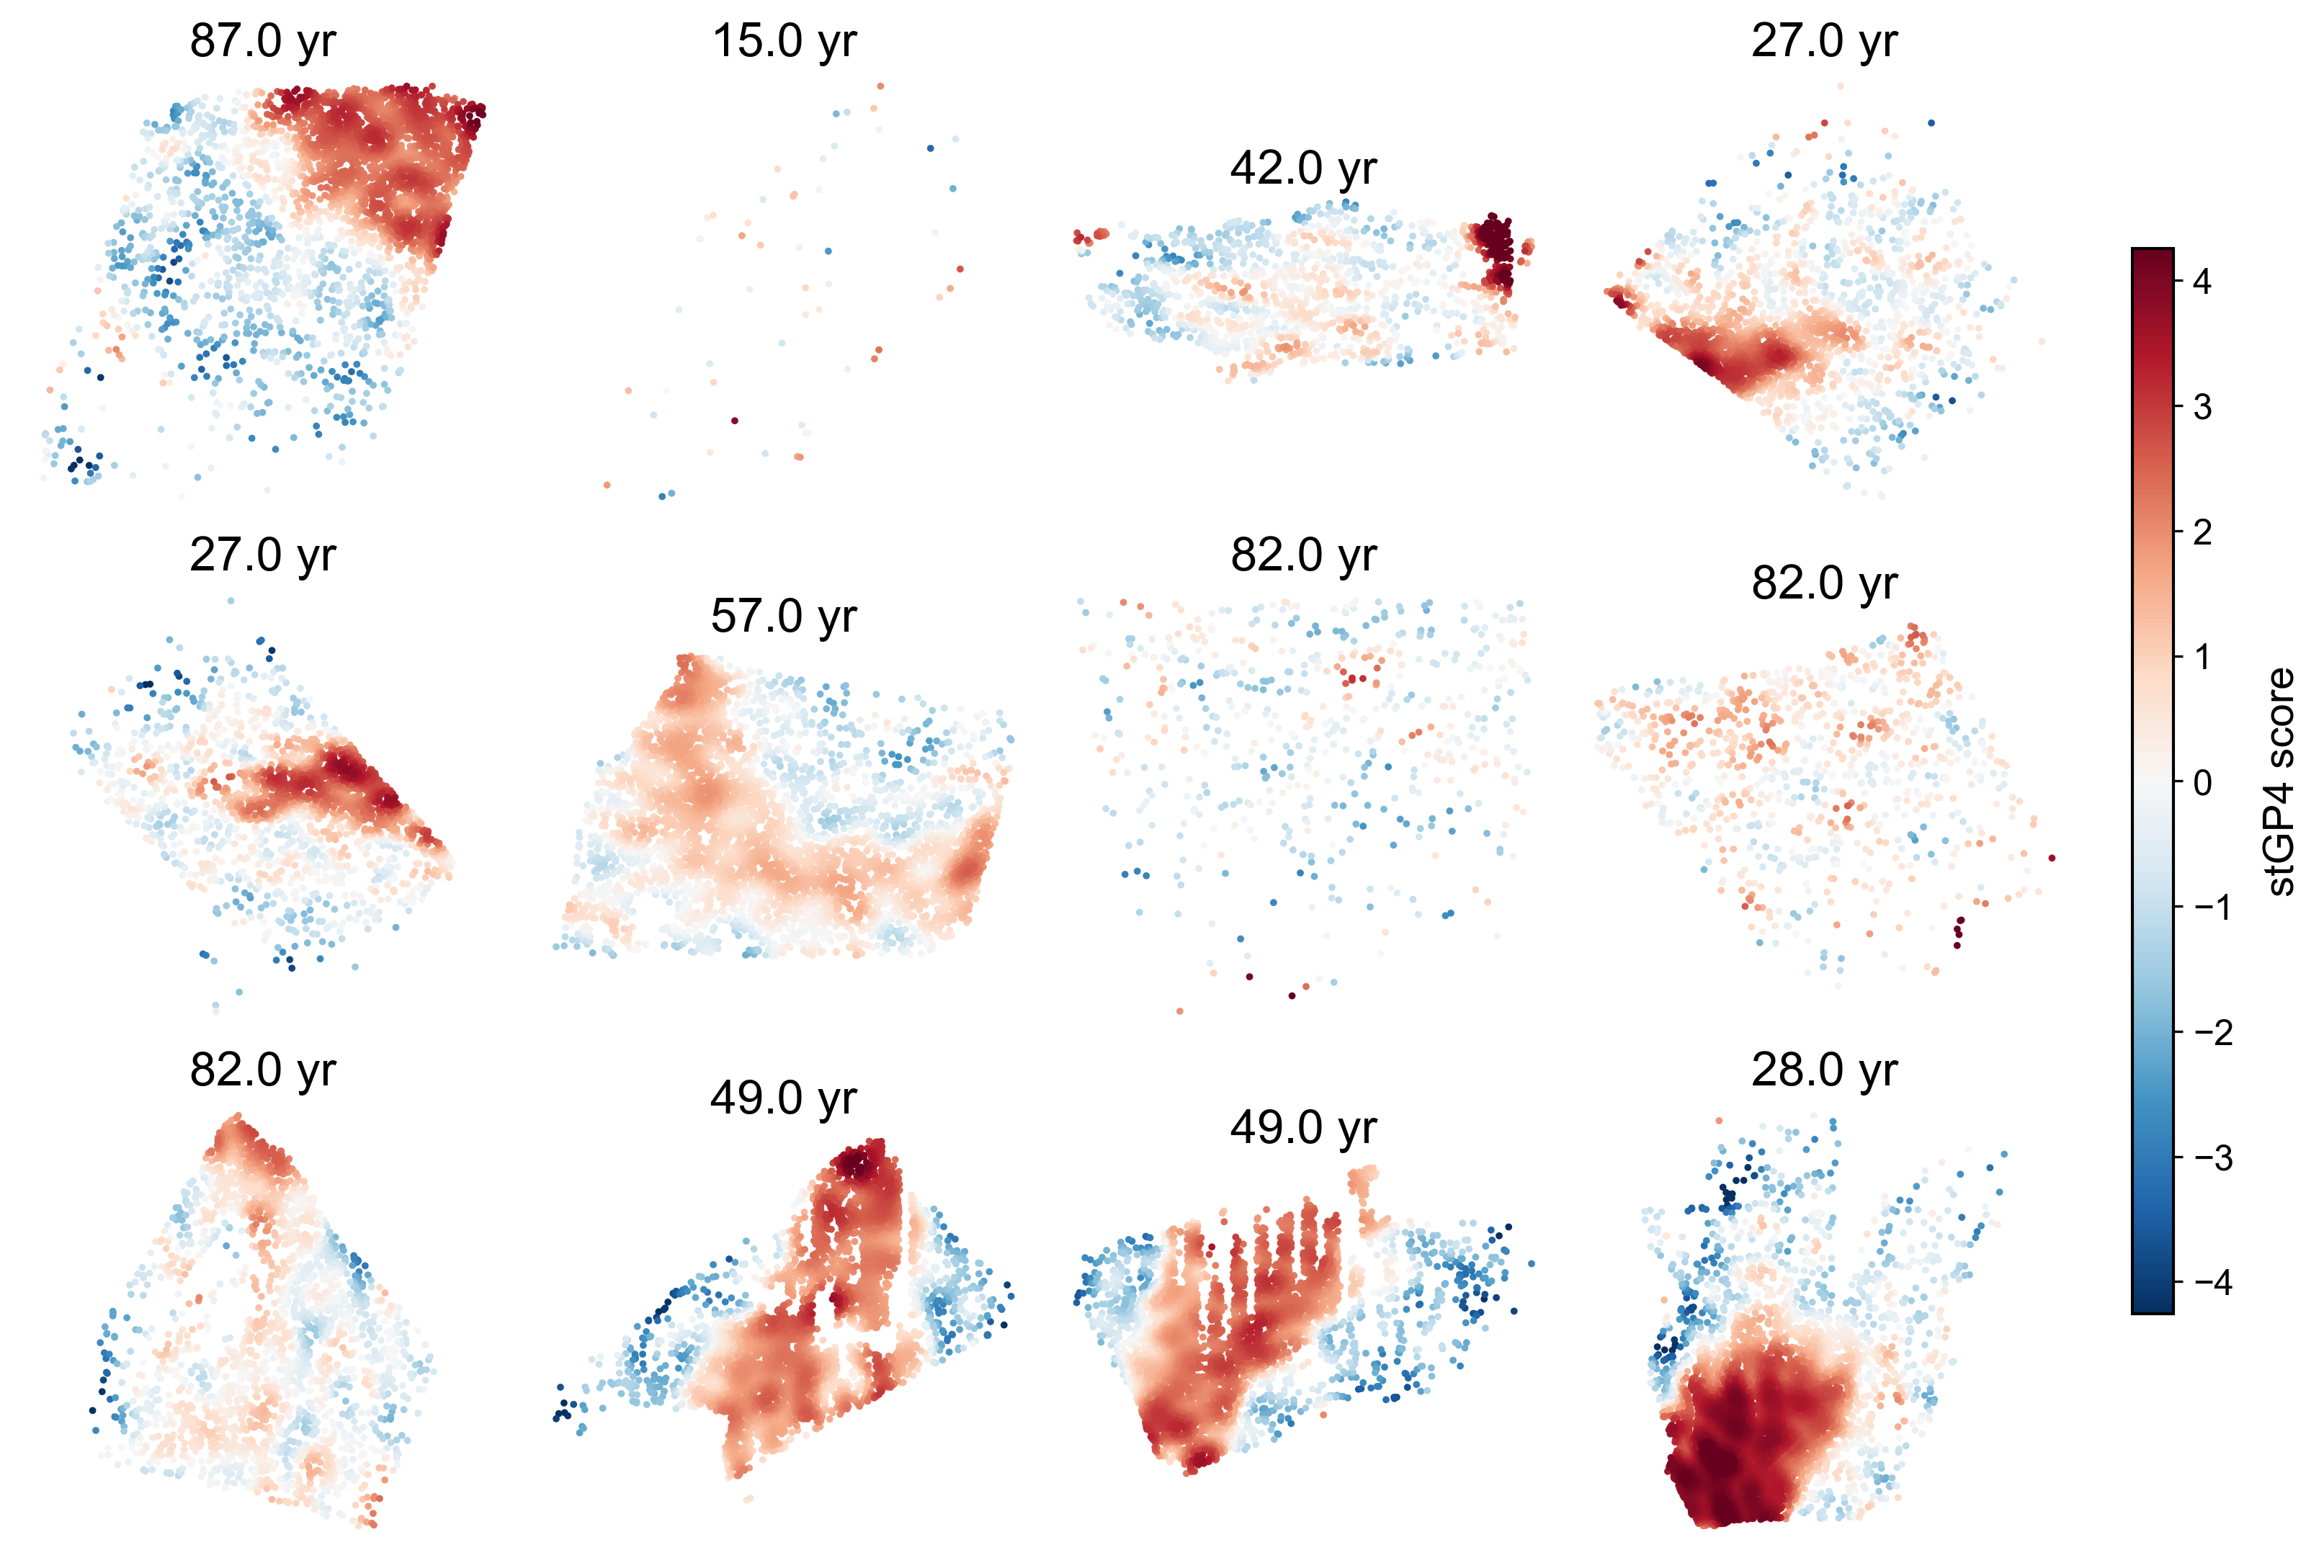

(PosixPath('/import/home4/byual/stGP-0707/FigureReproducing/human brain oli/spatial_stGP4.png'),
 PosixPath('/import/home4/byual/stGP-0707/FigureReproducing/human brain oli/spatial_stGP4.pdf'))

In [3]:
values = spatial_program_values(adata_oli, 'stGP4', allow_transpose=True)
groups = [str(g) for g in adata_oli.uns['stgp']['groups']]
ages = [float(a) for a in adata_oli.uns['stgp']['ages']]
xy = np.asarray(adata_oli.obsm['spatial'], dtype=float)
slice_ids = adata_oli.obs['id_region'].astype(str).to_numpy()

vmax = float(np.nanpercentile(np.abs(values), 99))
vmax = vmax if np.isfinite(vmax) and vmax > 0 else 1.0
fig, axes = plt.subplots(3, 4, figsize=(10.6, 7.7), constrained_layout=False)
fig.subplots_adjust(left=0.02, right=0.92, top=0.93, bottom=0.04, wspace=0.04, hspace=0.14)

sc_ref = None
for ax, sid, age in zip(axes.ravel(), groups, ages):
    mask = slice_ids == sid
    sub_xy = xy[mask]
    sub_v = values[mask]
    order = np.argsort(sub_v)
    sc_ref = ax.scatter(
        sub_xy[order, 0], sub_xy[order, 1],
        c=sub_v[order], cmap='RdBu_r', vmin=-vmax, vmax=vmax,
        s=5.5, linewidths=0, rasterized=True,
    )
    ax.set_title(f'{age:.1f} yr', fontsize=16, pad=3)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.axis('off')

cax = fig.add_axes([0.945, 0.18, 0.018, 0.64])
cbar = fig.colorbar(sc_ref, cax=cax)
cbar.set_label('stGP4 score', fontsize=14, labelpad=10)
cbar.ax.tick_params(labelsize=12, length=3)
save_pair(fig, 'spatial_stGP4', out_dir=OUT_DIR, bbox_inches='tight', pad_inches=0.03)


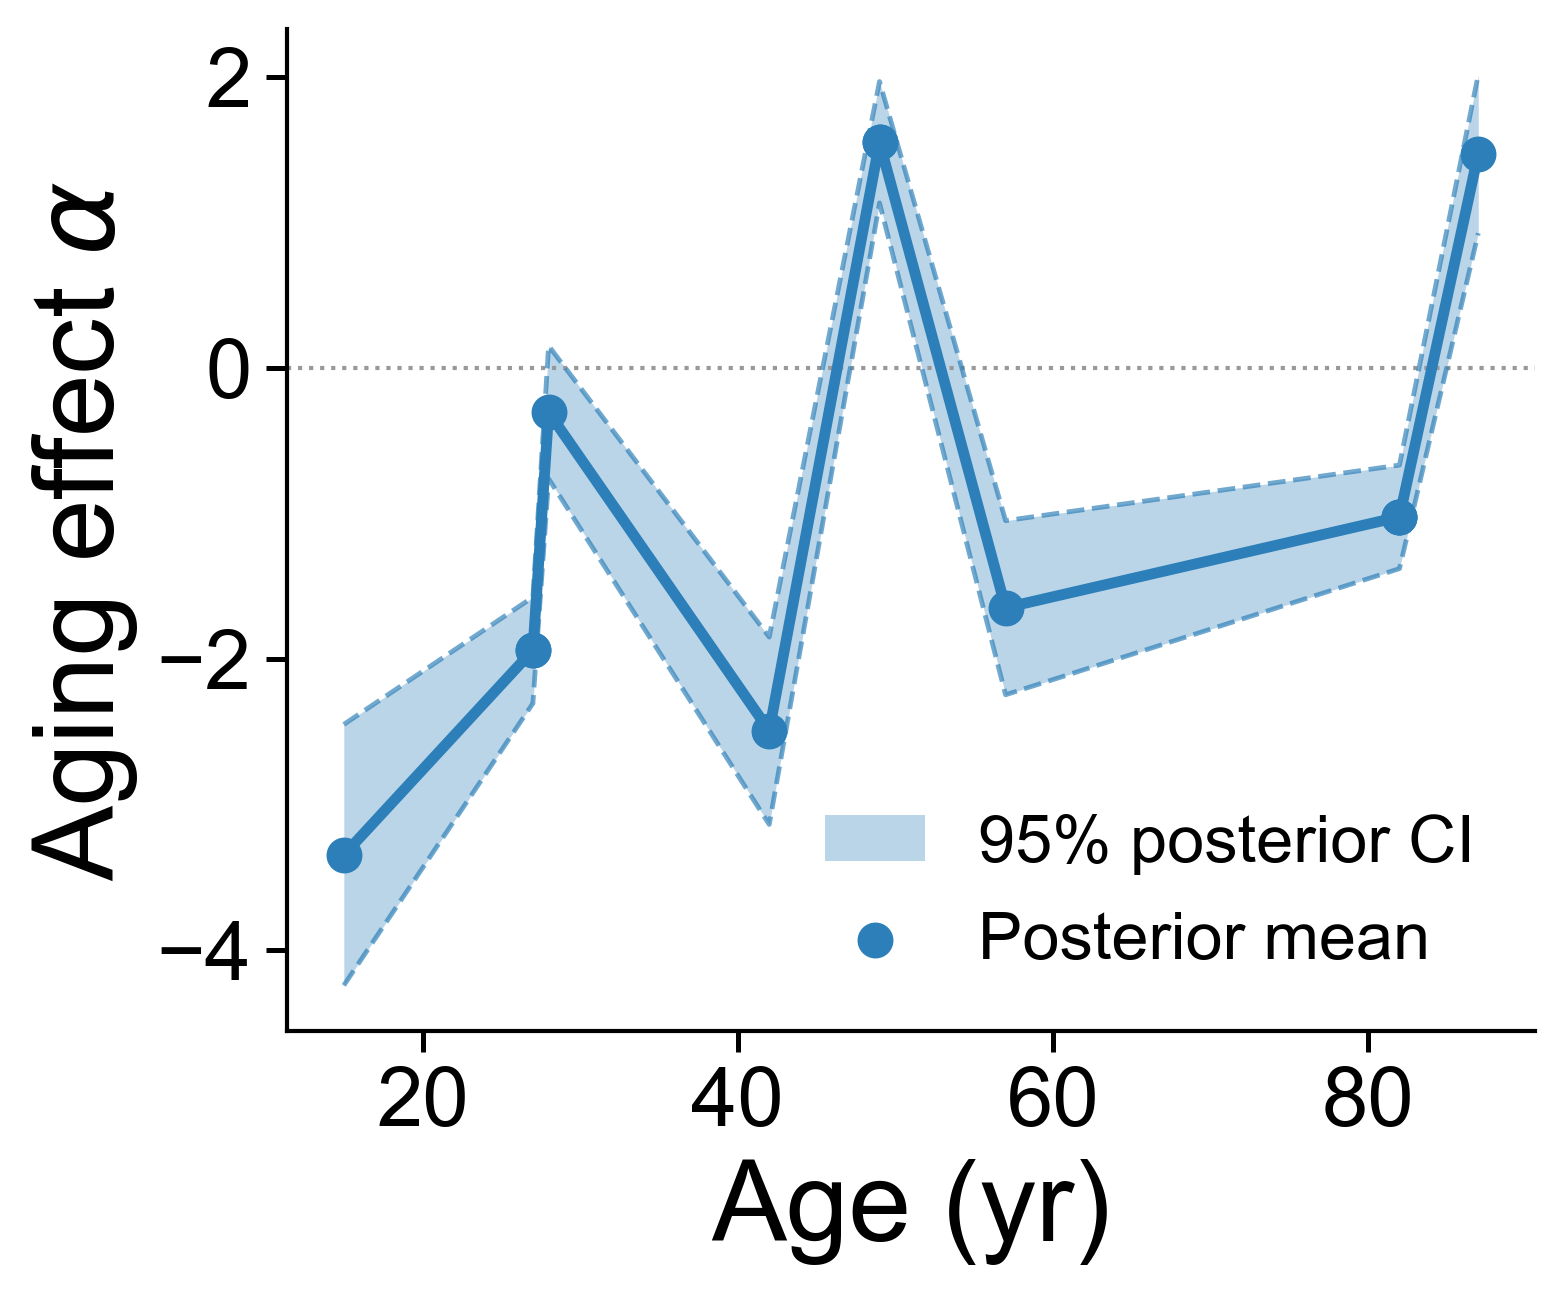

(PosixPath('/import/home4/byual/stGP-0707/FigureReproducing/human brain oli/alpha_trajectory_stGP4.png'),
 PosixPath('/import/home4/byual/stGP-0707/FigureReproducing/human brain oli/alpha_trajectory_stGP4.pdf'))

In [4]:
program_name = 'stGP4'
stem = 'alpha_trajectory_stGP4'
st = adata_oli.uns['stgp']
idx = int(program_name.replace('stGP', '')) - 1
x, y, lo, hi, _ = ordered_stgp_alpha(st, idx)

fig, ax = plt.subplots(figsize=(5.1, 4.2), constrained_layout=True)
draw_alpha_ci(
    ax,
    x,
    y,
    lo,
    hi,
    color='#2C7FB8',
    ci_fill_alpha=0.32,
    ci_line_lw=1.15,
    ci_line_alpha=0.68,
    line_lw=2.6,
    scatter_s=58,
    zero_line_color='0.60',
)
ax.set_xlabel('Age (yr)', fontsize=27)
ax.set_ylabel(r'Aging effect $\alpha$', fontsize=27)
ax.tick_params(labelsize=20, length=5, width=1.2)
ax.legend(fontsize=16, loc='lower right', frameon=False, handlelength=1.5, borderaxespad=0.5, labelspacing=0.55)
save_pair(fig, stem, out_dir=OUT_DIR, bbox_inches='tight', pad_inches=0.04)


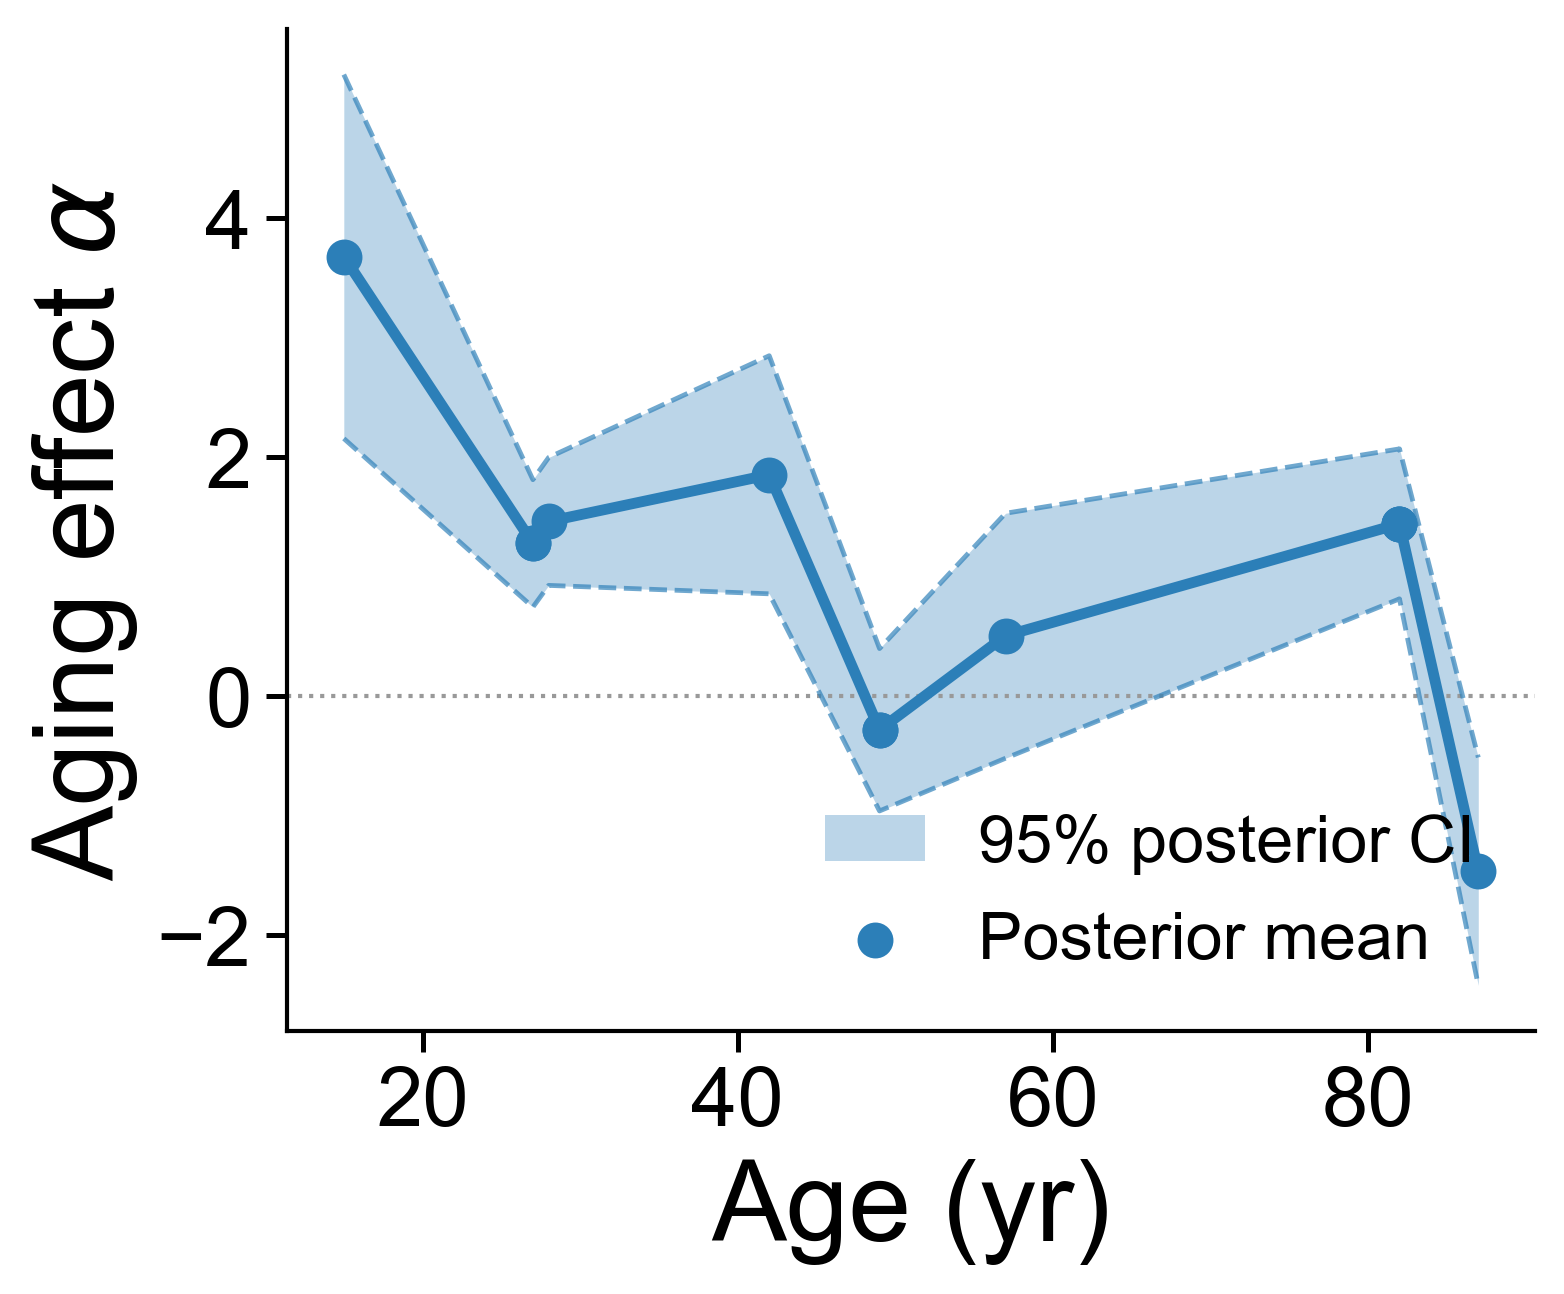

(PosixPath('/import/home4/byual/stGP-0707/FigureReproducing/human brain oli/alpha_trajectory_stGP1.png'),
 PosixPath('/import/home4/byual/stGP-0707/FigureReproducing/human brain oli/alpha_trajectory_stGP1.pdf'))

In [5]:
program_name = 'stGP1'
stem = 'alpha_trajectory_stGP1'
st = adata_oli.uns['stgp']
idx = int(program_name.replace('stGP', '')) - 1
x, y, lo, hi, _ = ordered_stgp_alpha(st, idx)

fig, ax = plt.subplots(figsize=(5.1, 4.2), constrained_layout=True)
draw_alpha_ci(
    ax,
    x,
    y,
    lo,
    hi,
    color='#2C7FB8',
    ci_fill_alpha=0.32,
    ci_line_lw=1.15,
    ci_line_alpha=0.68,
    line_lw=2.6,
    scatter_s=58,
    zero_line_color='0.60',
)
ax.set_xlabel('Age (yr)', fontsize=27)
ax.set_ylabel(r'Aging effect $\alpha$', fontsize=27)
ax.tick_params(labelsize=20, length=5, width=1.2)
ax.legend(fontsize=16, loc='lower right', frameon=False, handlelength=1.5, borderaxespad=0.5, labelspacing=0.55)
save_pair(fig, stem, out_dir=OUT_DIR, bbox_inches='tight', pad_inches=0.04)


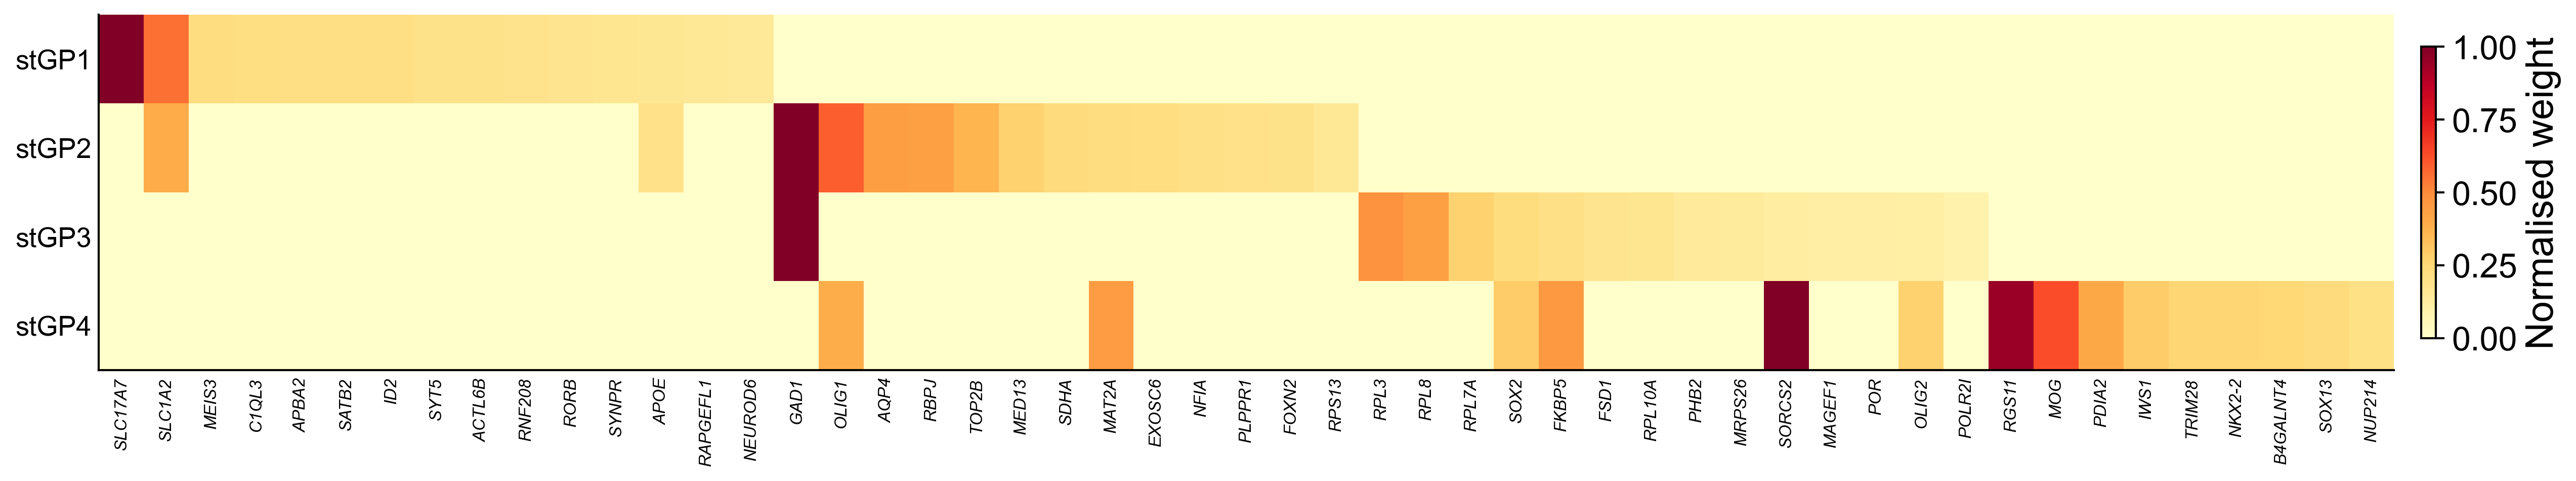

(PosixPath('/import/home4/byual/stGP-0707/FigureReproducing/human brain oli/W_heatmap.png'),
 PosixPath('/import/home4/byual/stGP-0707/FigureReproducing/human brain oli/W_heatmap.pdf'))

In [6]:
W_df = pd.read_csv(STGP_OLI_DIR / 'W.csv', index_col=0)
_, W_sub = ordered_gene_blocks(W_df, top_n_per_program=15)
top_genes = W_sub.columns.tolist()
W_norm = W_sub.div(W_sub.max(axis=1) + 1e-12, axis=0)

fig_w = min(0.34 * len(top_genes) + 2.8, 20)
fig, ax = plt.subplots(figsize=(fig_w, 3.9), constrained_layout=False)
im = ax.imshow(W_norm.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_yticks(range(len(W_norm.index)))
ax.set_yticklabels(W_norm.index, fontsize=13)
ax.set_xticks(range(len(top_genes)))
ax.set_xticklabels(top_genes, rotation=90, fontsize=8, fontstyle='italic')
ax.tick_params(length=0)
cbar = fig.colorbar(im, ax=ax, shrink=0.82, pad=0.01)
cbar.set_label('Normalised weight', fontsize=18)
cbar.ax.tick_params(labelsize=16, length=4, width=1.0)
fig.subplots_adjust(left=0.055, right=0.955, top=0.94, bottom=0.34)
save_pair(fig, 'W_heatmap', out_dir=OUT_DIR, bbox_inches='tight', pad_inches=0.04)

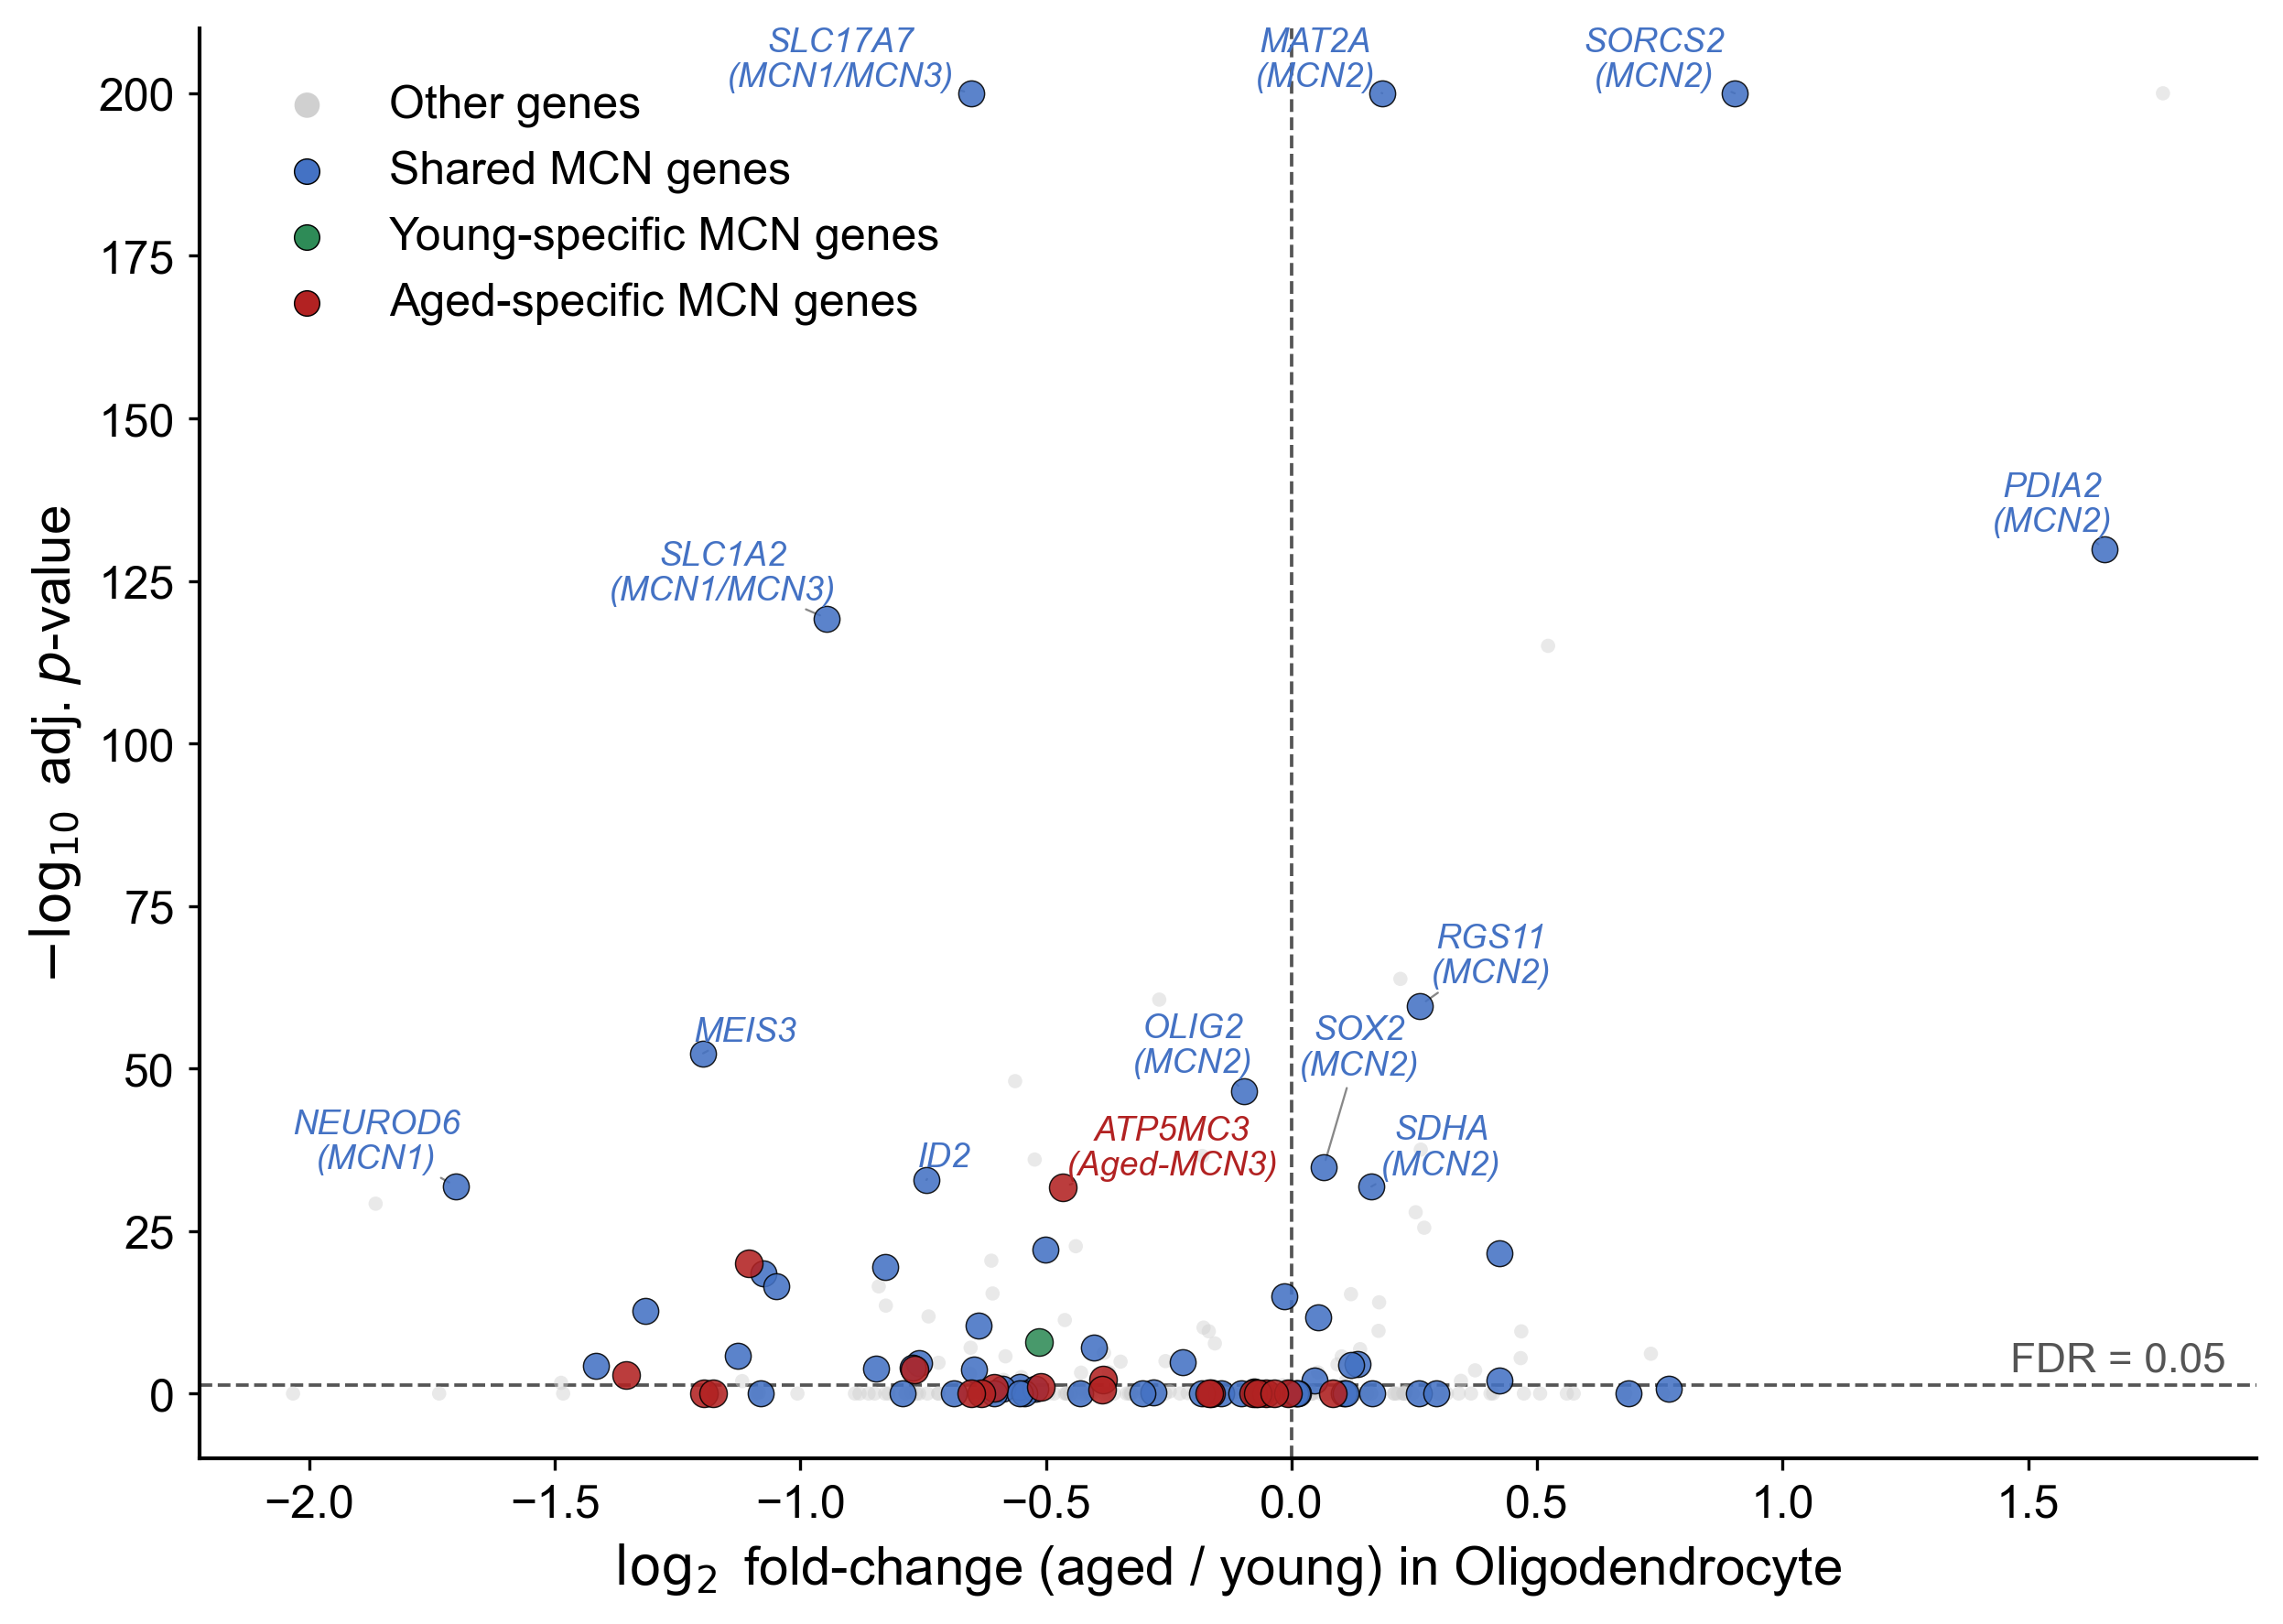

(PosixPath('/import/home4/byual/stGP-0707/FigureReproducing/human brain oli/ext_volcano_large.png'),
 PosixPath('/import/home4/byual/stGP-0707/FigureReproducing/human brain oli/ext_volcano_large.pdf'))

In [7]:
def mcn_gene_map(gene_df, prefix='', n_top=30, u_min=0.05):
    mapping = {}
    for comp, sub in gene_df.groupby('comp'):
        comp_num = int(str(comp).replace('comp', ''))
        label = f'{prefix}-MCN{comp_num}' if prefix else f'MCN{comp_num}'
        sub = sub.sort_values('rank').head(n_top)
        for _, row in sub.iterrows():
            if float(row['u']) >= u_min:
                mapping.setdefault(str(row['gene']), []).append(label)
    return mapping


de_df = pd.read_csv(NICHESCOPE_OLI_DIR / 'microglia_DE_aged_vs_young.csv')
with open(NICHESCOPE_OLI_DIR / 'aging_gene_lists.json') as f:
    lists = json.load(f)
shared = pd.read_csv(NICHESCOPE_OLI_DIR / 'genes_shared.csv')
young = pd.read_csv(NICHESCOPE_OLI_DIR / 'genes_young.csv')
aged = pd.read_csv(NICHESCOPE_OLI_DIR / 'genes_old.csv')

young_only = set(lists.get('young_only', []))
aged_only = set(lists.get('aged_only', []))
common = set(lists.get('common_young_aged', [])) | set(lists.get('shared_only', []))
mcn_common = mcn_gene_map(shared, '')
mcn_young = mcn_gene_map(young, 'Young')
mcn_aged = mcn_gene_map(aged, 'Aged')

x = de_df['log2fc_aged_vs_young'].to_numpy(float)
y = -np.log10(np.clip(de_df['adj_p'].to_numpy(float), 1e-200, 1.0))
genes = de_df['gene'].astype(str)
masks = {
    'other': ~(genes.isin(young_only | aged_only | common)),
    'common': genes.isin(common),
    'young': genes.isin(young_only),
    'aged': genes.isin(aged_only),
}
colors = {'other': '#D0D0D0', 'common': '#4472C4', 'young': '#2E8B57', 'aged': '#B22222'}
labels = {'other': 'Other genes', 'common': 'Shared MCN genes', 'young': 'Young-specific MCN genes', 'aged': 'Aged-specific MCN genes'}
sizes = {'other': 14, 'common': 46, 'young': 52, 'aged': 52}

fig, ax = plt.subplots(figsize=(8.2, 5.8), constrained_layout=True)
for key in ['other', 'common', 'young', 'aged']:
    ax.scatter(
        x[masks[key]], y[masks[key]],
        s=sizes[key], c=colors[key], alpha=0.46 if key == 'other' else 0.88,
        edgecolors='none' if key == 'other' else 'black',
        linewidths=0 if key == 'other' else 0.35,
        label=labels[key], rasterized=(key == 'other'), zorder=2 if key == 'other' else 3,
    )

fdr_y = -np.log10(0.05)
ax.axhline(fdr_y, ls='--', c='#555555', lw=0.9, zorder=1)
ax.axvline(0, ls='--', c='#555555', lw=0.9, zorder=1)
ax.text(0.985, fdr_y + 0.9, 'FDR = 0.05', fontsize=11, color='#555555', ha='right', va='bottom', transform=ax.get_yaxis_transform())

de_idx = de_df.set_index('gene')
texts = []
for gene_set, mapping, color in [(aged_only, mcn_aged, colors['aged']), (young_only, mcn_young, colors['young']), (common, mcn_common, colors['common'])]:
    for gene in gene_set:
        if gene not in de_idx.index:
            continue
        row = de_idx.loc[gene]
        if float(row['adj_p']) > 1e-25:
            continue
        gx = float(row['log2fc_aged_vs_young'])
        gy = float(-np.log10(max(float(row['adj_p']), 1e-200)))
        mcn = '/'.join(mapping.get(gene, []))
        label = f'{gene}\n({mcn})' if mcn else gene
        texts.append(ax.text(gx, gy, label, fontsize=9, color=color, fontstyle='italic', linespacing=1.15, ha='center', va='bottom'))
if texts:
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='#888888', lw=0.55), expand=(1.2, 1.45), force_text=(0.35, 0.55), time_lim=7)

ax.set_xlabel(r'$\log_2$ fold-change (aged / young) in Oligodendrocyte', fontsize=14)
ax.set_ylabel(r'$-\log_{10}$ adj. $p$-value', fontsize=14)
ax.tick_params(labelsize=12)
leg = ax.legend(frameon=False, fontsize=12, loc='upper left', bbox_to_anchor=(0.01, 0.99))
for handle in leg.legend_handles:
    try:
        handle.set_sizes([44])
        handle.set_alpha(1)
    except Exception:
        pass
save_pair(fig, 'ext_volcano_large', out_dir=OUT_DIR, bbox_inches='tight', pad_inches=0.04)


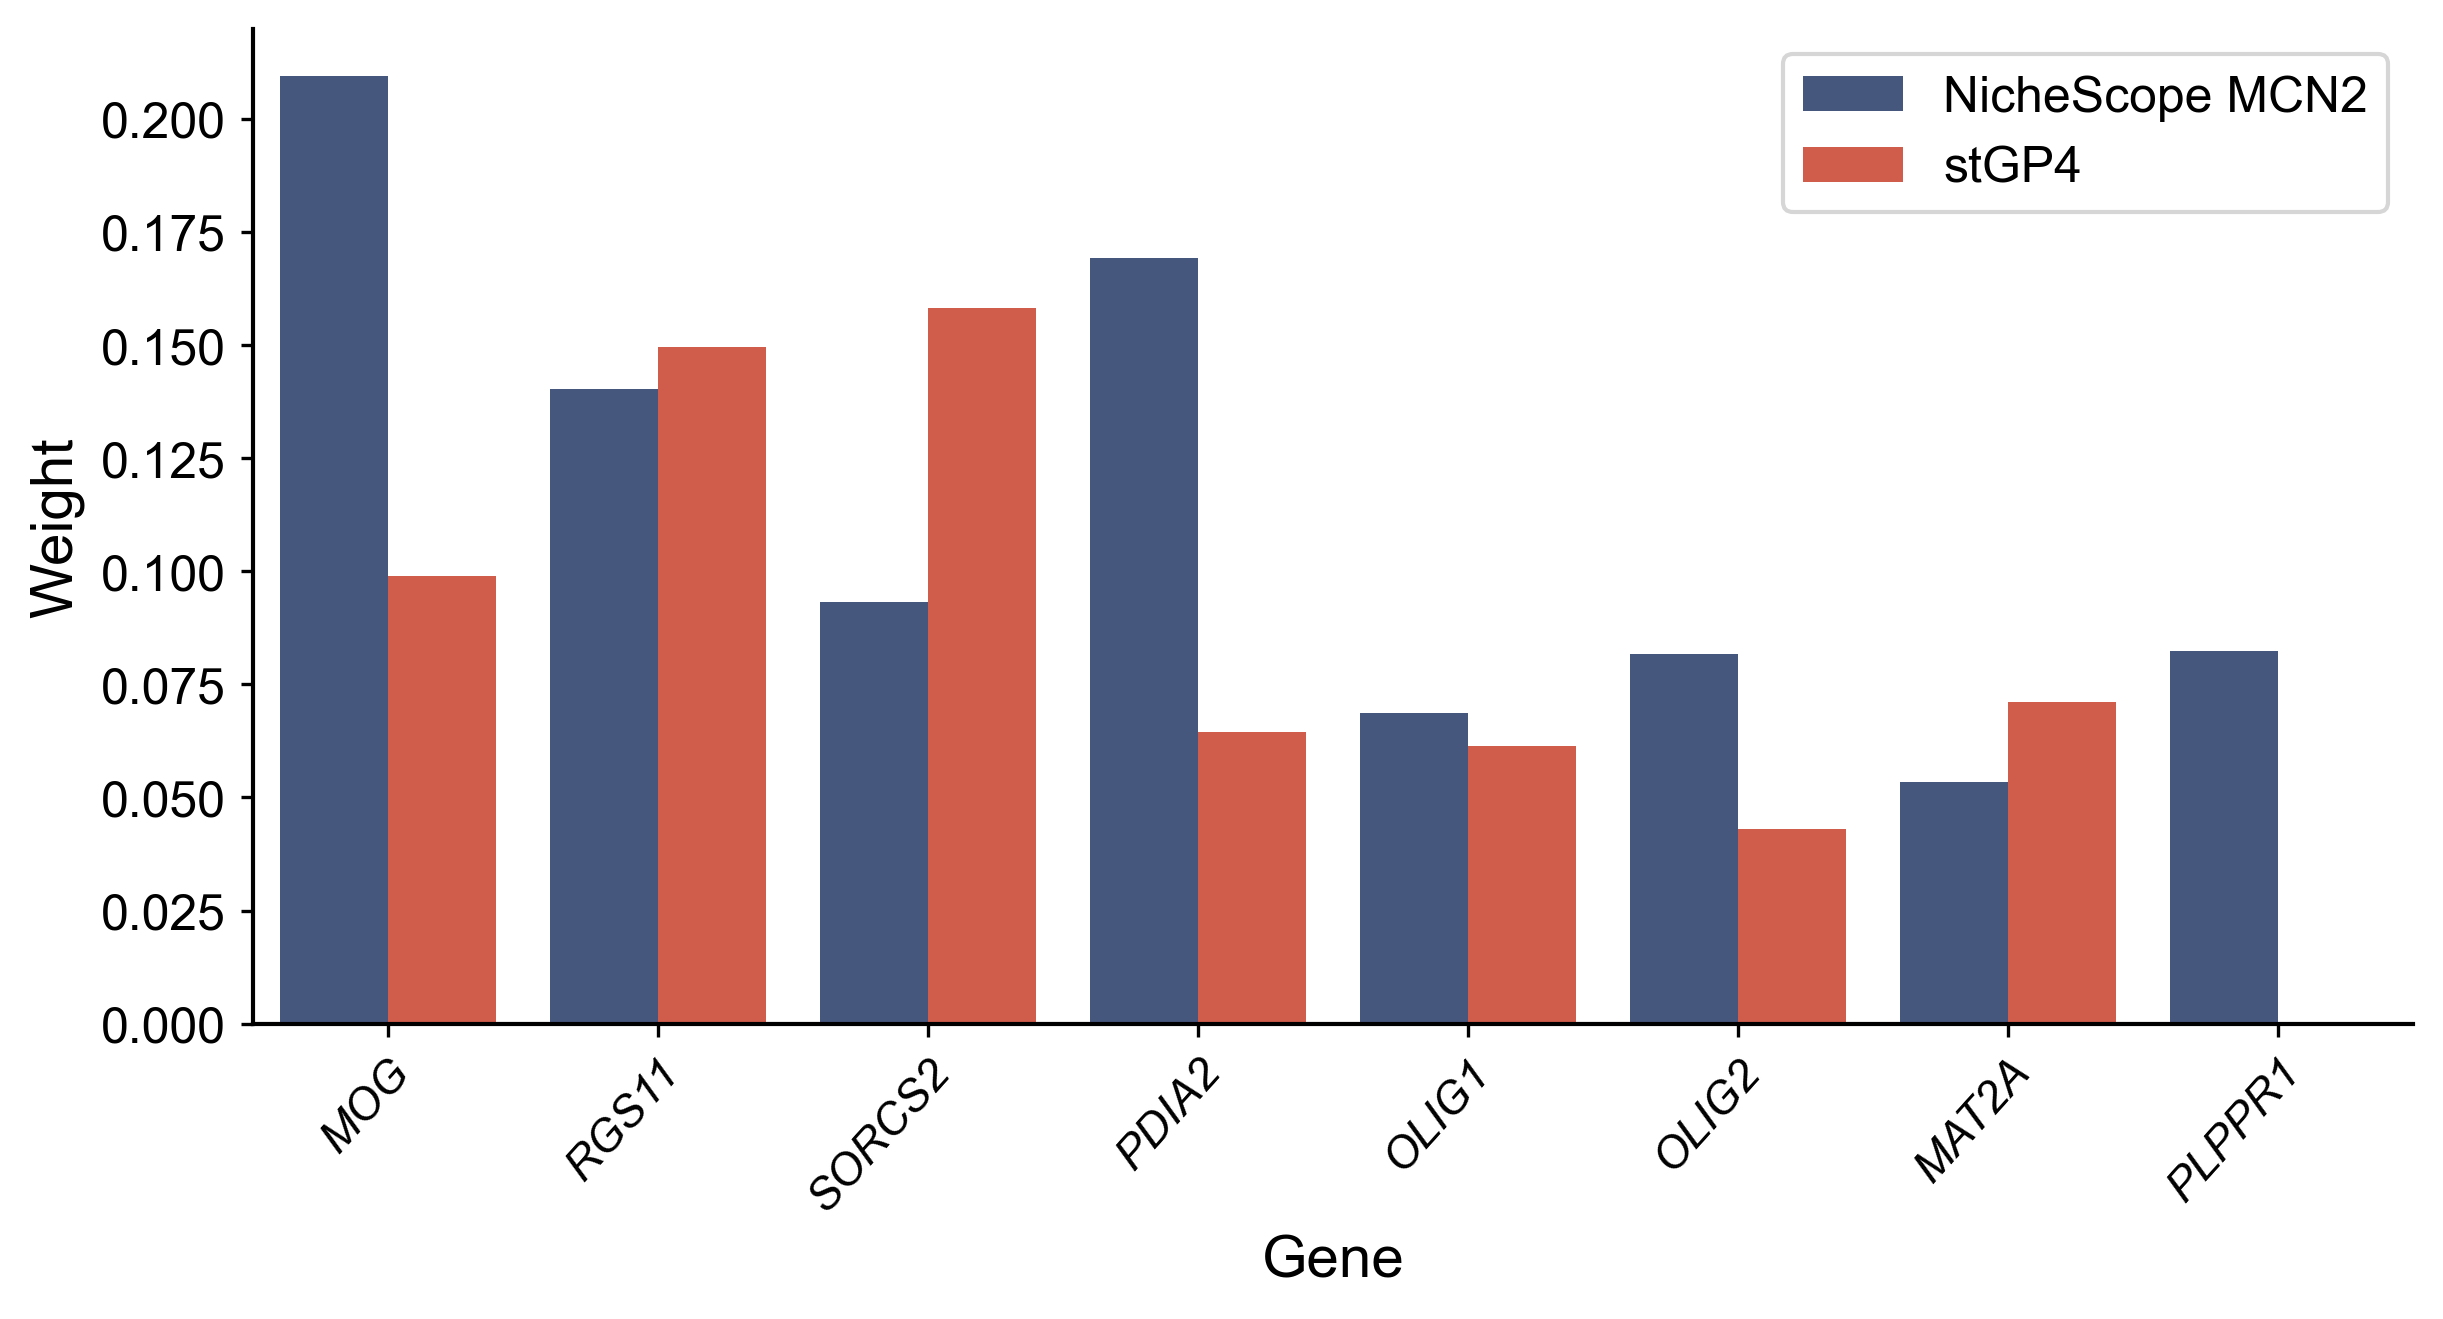

(PosixPath('/import/home4/byual/stGP-0707/FigureReproducing/human brain oli/mcn_union_oli_stGP4_loadings.png'),
 PosixPath('/import/home4/byual/stGP-0707/FigureReproducing/human brain oli/mcn_union_oli_stGP4_loadings.pdf'))

In [8]:
shared = pd.read_csv(NICHESCOPE_OLI_DIR / 'genes_shared.csv')
active = pd.read_csv(MCN_UNION_STGP_OLI_DIR / 'W_active_genes.csv')
focus_comp = 'comp2'
focus_program = 'stGP4'
mcn = shared[shared['comp'] == focus_comp].sort_values('rank').head(10)
prog = active[active['program'] == focus_program].nsmallest(10, 'rank').sort_values('weight', ascending=False)
genes = sorted(set(mcn['gene']) | set(prog['gene']))
mcn_s = mcn.set_index('gene')['u']
stgp_s = prog.set_index('gene')['weight']
tbl = pd.DataFrame({'gene': genes, 'NicheScope MCN2': [mcn_s.get(g, np.nan) for g in genes], 'stGP4': [stgp_s.get(g, np.nan) for g in genes]})
denom = tbl['NicheScope MCN2'].fillna(0).abs().sum()
if denom > 0:
    tbl['NicheScope MCN2'] = tbl['NicheScope MCN2'] / denom
order_score = tbl[['NicheScope MCN2', 'stGP4']].fillna(0).abs().sum(axis=1)
gene_order = tbl.loc[order_score.sort_values(ascending=False).index, 'gene'].tolist()[:8]
tbl = tbl[tbl['gene'].isin(gene_order)].copy()
plot_df = tbl.melt(id_vars='gene', var_name='source', value_name='loading')
plot_df['gene'] = pd.Categorical(plot_df['gene'], categories=gene_order, ordered=True)

fig_w = max(8.0, 0.62 * len(gene_order) + 2.4)
fig, ax = plt.subplots(figsize=(fig_w, 5.1), constrained_layout=False)
sns.barplot(data=plot_df, x='gene', y='loading', hue='source', hue_order=['NicheScope MCN2', 'stGP4'], palette={'NicheScope MCN2': NICHE_COLOR, 'stGP4': STGP_COLOR}, ax=ax)
ax.axhline(0, color='0.82', lw=1.0, zorder=0)
ax.set_xlabel('Gene', fontsize=14)
ax.set_ylabel('Weight', fontsize=14)
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=11)
plt.setp(ax.get_xticklabels(), rotation=48, ha='right', rotation_mode='anchor', fontstyle='italic')
ax.legend(frameon=True, fontsize=12, loc='upper right')
fig.subplots_adjust(left=0.08, right=0.98, top=0.95, bottom=0.30)
save_pair(fig, 'mcn_union_oli_stGP4_loadings', out_dir=OUT_DIR, bbox_inches='tight', pad_inches=0.04)


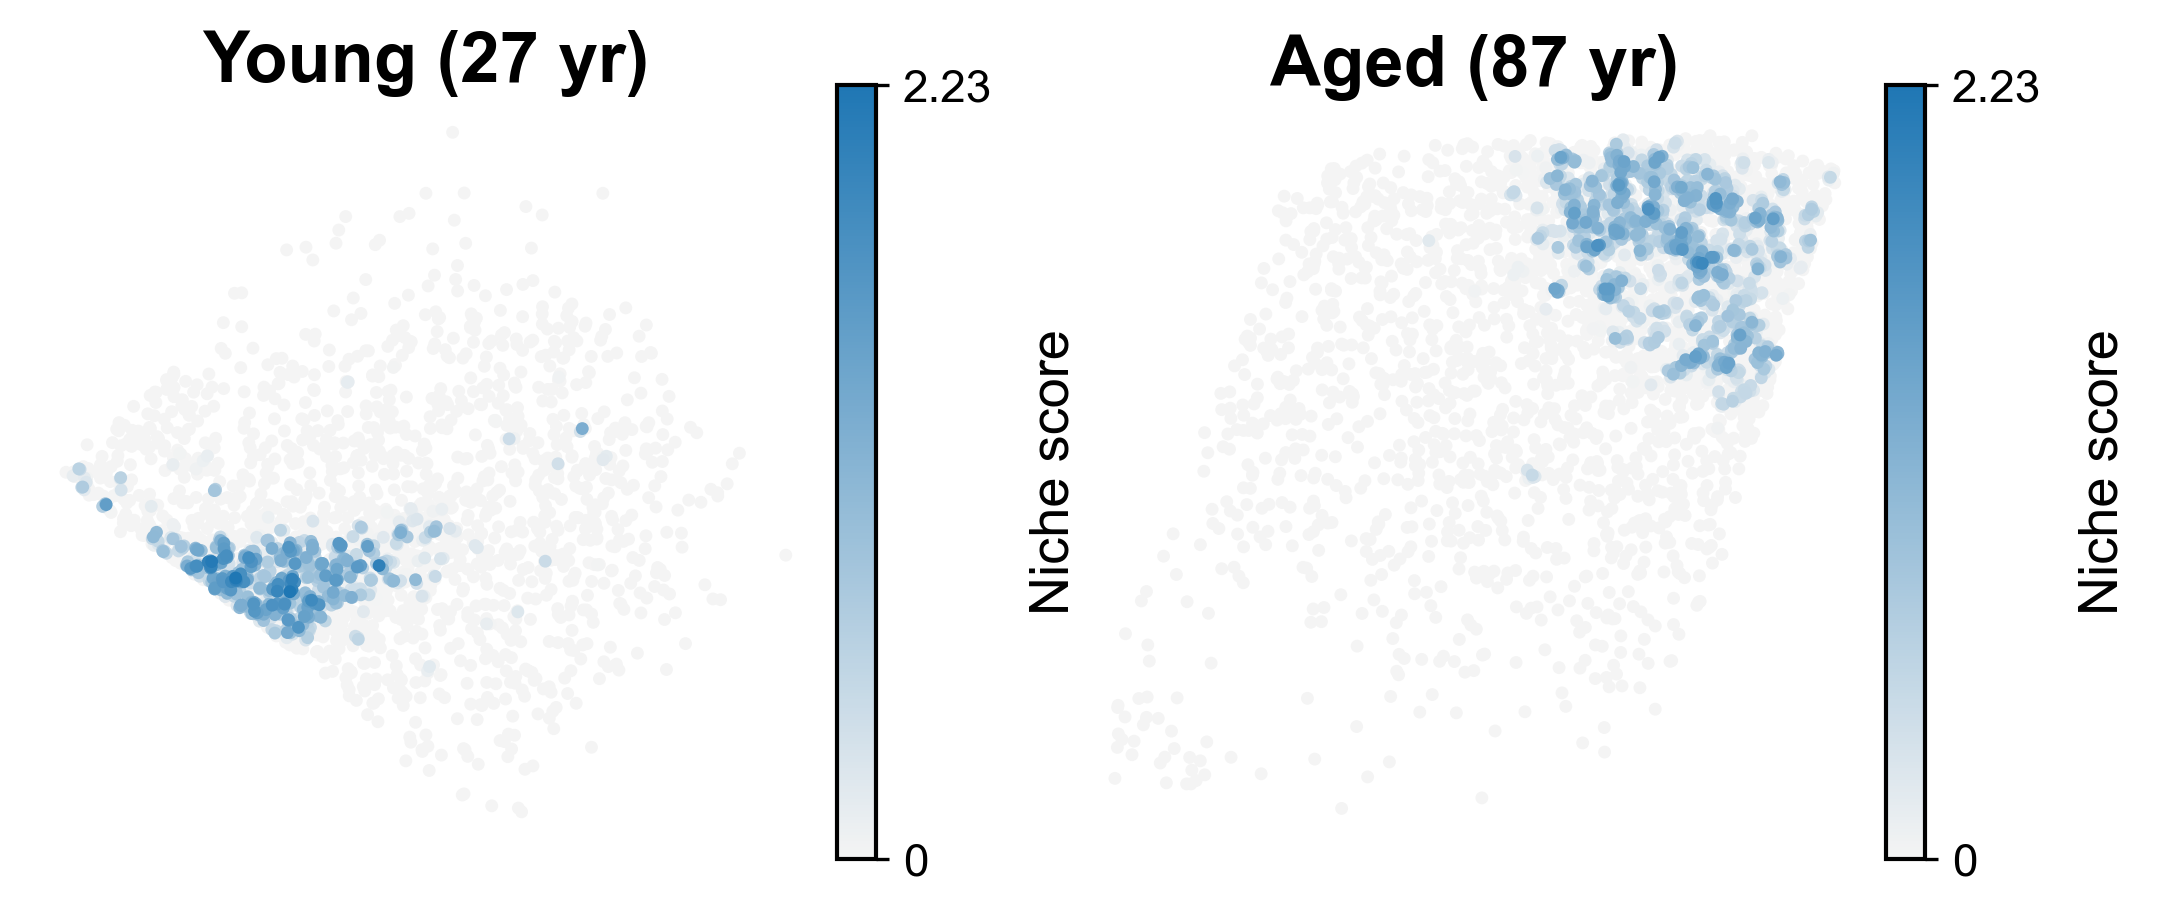

(PosixPath('/import/home4/byual/stGP-0707/FigureReproducing/human brain oli/score_shared_2.png'),
 PosixPath('/import/home4/byual/stGP-0707/FigureReproducing/human brain oli/score_shared_2.pdf'))

In [9]:
pkl = NICHESCOPE_OLI_DIR / 'meta_share_microglia.pkl'
with open(pkl, 'rb') as f:
    meta_share = pickle.load(f)
score_df1 = meta_share['score_df1']
score_df2 = meta_share['score_df2']
comp = 'S_comp2'
if comp not in score_df1.columns or comp not in score_df2.columns:
    raise KeyError(f'{comp} missing from NicheScope score tables')

global_vmax = max(float(score_df1[comp].max()), float(score_df2[comp].max()), 1e-6)
cmap = mpl.colors.LinearSegmentedColormap.from_list('score_shared_2_cmap', ['#F4F4F4', '#1f77b4'], N=256)
fig, axes = plt.subplots(1, 2, figsize=(8.15, 3.35), gridspec_kw={'wspace': 0.24})
for ax, sdf, ttl in zip(axes, [score_df1, score_df2], ['Young (27 yr)', 'Aged (87 yr)']):
    xy = sdf[['x', 'y']].to_numpy(float)
    score = sdf[comp].to_numpy(float)
    ax.scatter(xy[:, 0], xy[:, 1], s=2.0, c='#EDEDED', linewidths=0, rasterized=True)
    order = np.argsort(score)
    sc = ax.scatter(xy[order, 0], xy[order, 1], c=score[order], s=9.5, cmap=cmap, vmin=0, vmax=global_vmax, linewidths=0, rasterized=True)
    ax.set_title(ttl, fontsize=17, fontweight='bold', pad=4)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.axis('off')
    cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.018)
    cbar.set_label('Niche score', fontsize=13, labelpad=9)
    cbar.ax.tick_params(labelsize=11, length=3)
    cbar.set_ticks([0, global_vmax])
    cbar.set_ticklabels(['0', f'{global_vmax:.2f}'])
save_pair(fig, 'score_shared_2', out_dir=OUT_DIR, bbox_inches='tight', pad_inches=0.04)
